# 환율(USD·JPY·CNY) 시계열 트렌드 분석

이 노트북은 원/달러(USD), 원/엔(JPY, 1엔 기준), 원/위안(CNY) 3개 환율의
2023-01-01 ~ 2026-08-31 영업일 데이터를 분석합니다(2025~2026년 데이터 포함).

- 데이터: 한국수출입은행 Open API(`src/fetch_data.py`)로 수집 → SQLite 캐시
  (샌드박스 네트워크 제한으로 이번 실행에는 동일 스키마의 샘플 데이터 사용,
  `src/generate_sample_data.py` 참고)
- 분석 기법: 이동평균, 일간 변화율/변동성, 월별 수익률, 시계열 분해, 베이스라인 예측


In [1]:
import sys, os
sys.path.insert(0, "src")
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import analyze as az

import matplotlib.font_manager as fm
for f in fm.fontManager.ttflist:
    if "Nanum" in f.name:
        plt.rcParams["font.family"] = f.name
        break
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
os.makedirs("images", exist_ok=True)

DB_PATH = "data/exchange_rates.db"


## 1. 데이터 기본 정보 확인

In [2]:
long_df = az.load_long_df(DB_PATH)
wide_raw = az.to_wide(long_df)
print("기간:", wide_raw.index.min().date(), "~", wide_raw.index.max().date())
print("행(영업일) 수:", len(wide_raw))
print("컬럼:", list(wide_raw.columns))
print("\n결측치 개수:")
print(wide_raw.isna().sum())
wide_raw.describe()


기간: 2023-01-02 ~ 2026-08-31
행(영업일) 수: 956
컬럼: ['CNY', 'JPY', 'USD']

결측치 개수:
currency
CNY    5
JPY    0
USD    0
dtype: int64


currency,CNY,JPY,USD
count,951.000000,956.000000,956.000000
mean,177.471157,8.612949,1295.001527
std,4.151744,0.738306,28.003399
min,169.700000,7.266000,1195.870000
25%,173.680000,7.917000,1271.250000
50%,178.080000,8.849000,1292.670000
75%,180.740000,9.280000,1315.900000
max,185.890000,9.722000,1356.340000


## 2. 결측치/이상치 처리

- **결측치**: 영업일 시계열 특성상 값이 하루 이틀 비는 것은 선형보간(interpolate)으로 채움.
- **이상치**: 통화별 z-score 기준 `|z| > 3`인 지점을 이상치로 간주, 결측 처리 후 보간으로 대체.
  (AI 보조: 임계값 후보로 IQR 1.5배 vs z-score 3배를 비교 검토 — REPORT.md §7 AI 사용 로그 참고)


In [3]:
wide, clean_report = az.clean(wide_raw, z_thresh=3.0)
print("전처리 요약 (결측 보간 건수 / 이상치 대체 건수):")
for k, v in clean_report.items():
    print(f"  {k}: {v}")


전처리 요약 (결측 보간 건수 / 이상치 대체 건수):
  CNY: {'missing_filled': 5, 'outliers_replaced': 0}
  JPY: {'missing_filled': 0, 'outliers_replaced': 0}
  USD: {'missing_filled': 0, 'outliers_replaced': 1}


## 3. 분석 질문

1. 2023~2026년(현재까지) 동안 USD/JPY/CNY는 각각 상승·하락 추세를 보였는가?
2. 변동성(변화율의 표준편차)이 특히 커진 구간은 언제이며, 통화 간 차이가 있는가?
3. 월별 수익률에 계절적/주기적 패턴이 존재하는가?
4. (보너스) 추세와 계절성을 분리했을 때 무엇이 드러나는가? 단순 베이스라인으로 향후 며칠을 예측하면 어떤 가정과 한계가 따르는가?


## 4. 시각화 1 — 환율 추세 (원본 vs 20일 이동평균)

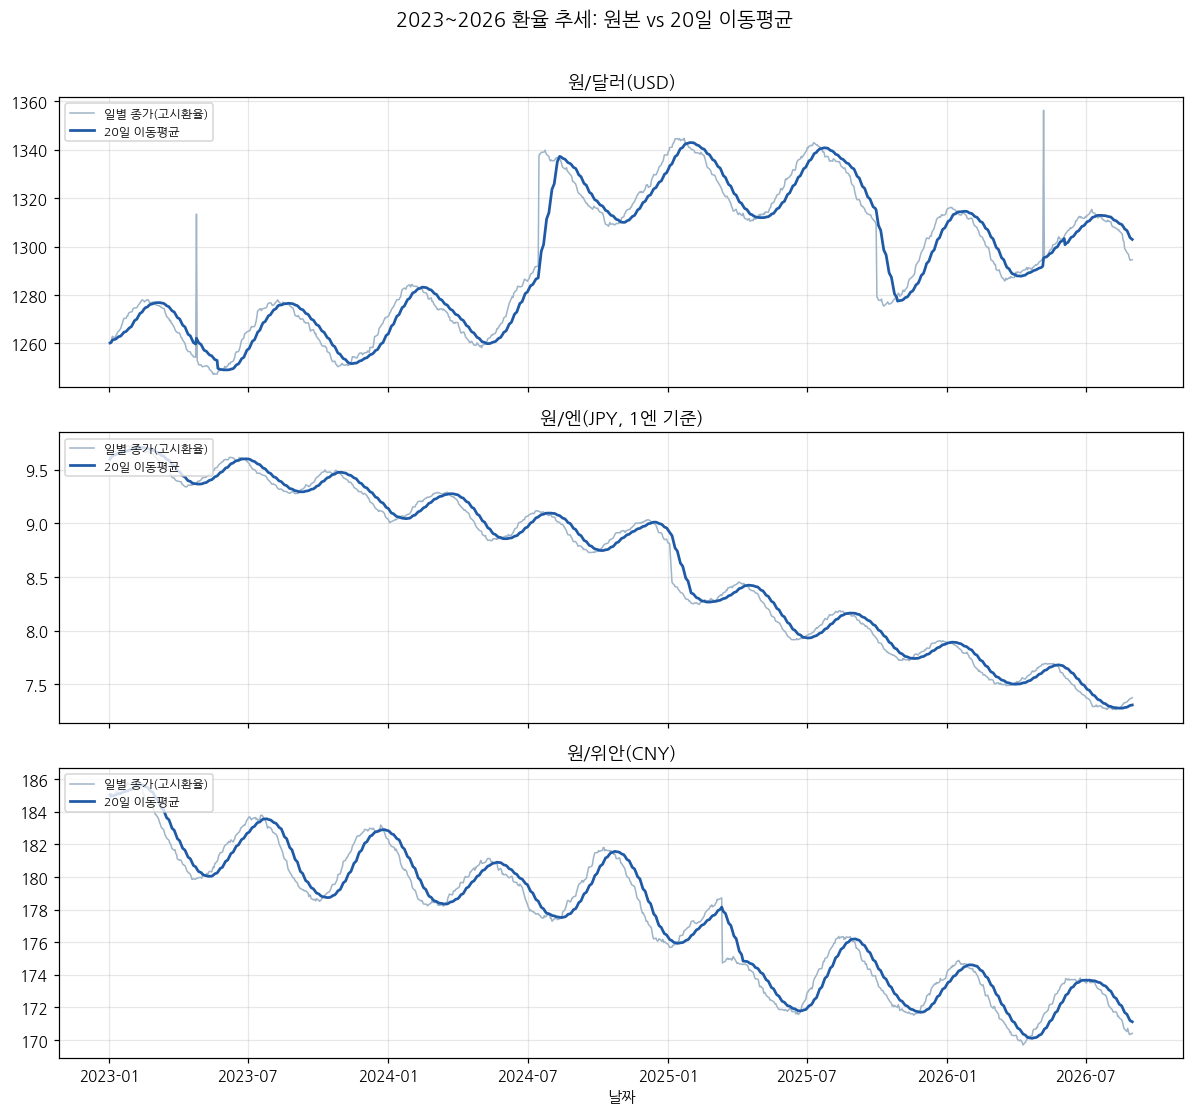

In [4]:
ma20 = az.moving_average(wide, window=20)

fig, axes = plt.subplots(3, 1, figsize=(11, 10), sharex=True)
titles = {"USD": "원/달러(USD)", "JPY": "원/엔(JPY, 1엔 기준)", "CNY": "원/위안(CNY)"}
for ax, col in zip(axes, ["USD", "JPY", "CNY"]):
    ax.plot(wide.index, wide[col], color="#9fb4c7", lw=1, label="일별 종가(고시환율)")
    ax.plot(ma20.index, ma20[col], color="#1f5aa6", lw=1.8, label="20일 이동평균")
    ax.set_title(titles[col])
    ax.legend(loc="upper left", fontsize=8)
axes[-1].set_xlabel("날짜")
fig.suptitle("2023~2026 환율 추세: 원본 vs 20일 이동평균", y=1.01, fontsize=13)
fig.tight_layout()
fig.savefig("images/01_price_trend.png", bbox_inches="tight")
plt.show()


**관찰**: 그래프의 스케일이 통화마다 크게 달라(USD ~1200원대, JPY ~9원대, CNY ~180원대)
하나의 축에 겹쳐 그리면 왜곡되므로 통화별로 서브플롯을 분리했다. (시각화 선택 가이드 반영)


## 5. 시각화 2 — 일간 변화율 및 20일 롤링 변동성

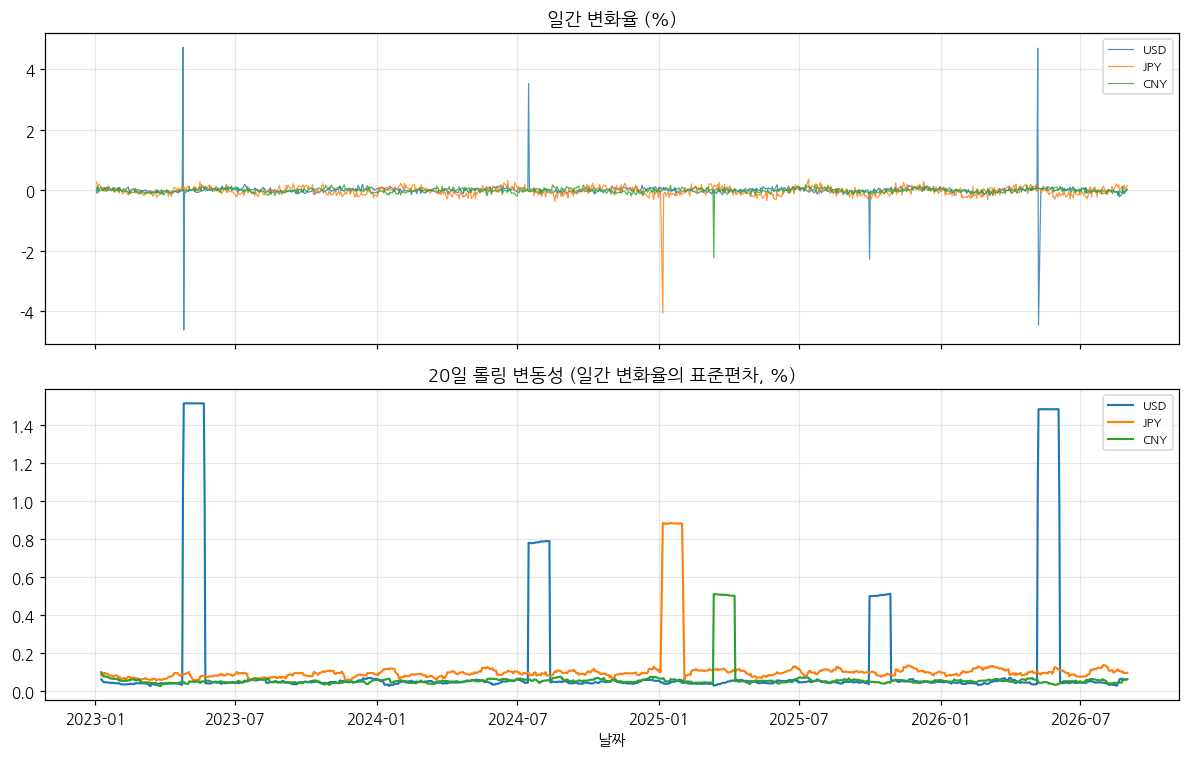

통화별 변동성 요약 (전체 기간 표준편차, %):
currency
CNY    0.099554
JPY    0.178951
USD    0.334200
dtype: float64

변동성이 가장 컸던 시점 (통화별 상위 3일):
-- USD --
date
2023-05-05    1.514687
2023-05-01    1.514683
2023-05-04    1.514670
Name: USD, dtype: float64
-- JPY --
date
2025-01-16    0.884421
2025-01-17    0.883812
2025-01-07    0.883790
Name: JPY, dtype: float64
-- CNY --
date
2025-03-13    0.510335
2025-03-14    0.510166
2025-03-17    0.508947
Name: CNY, dtype: float64


In [5]:
ret = az.daily_return(wide)
vol = az.rolling_volatility(wide, window=20)

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
for col in ["USD", "JPY", "CNY"]:
    axes[0].plot(ret.index, ret[col], lw=0.8, alpha=0.8, label=col)
    axes[1].plot(vol.index, vol[col], lw=1.4, label=col)
axes[0].set_title("일간 변화율 (%)")
axes[1].set_title("20일 롤링 변동성 (일간 변화율의 표준편차, %)")
axes[0].legend(fontsize=8)
axes[1].legend(fontsize=8)
axes[1].set_xlabel("날짜")
fig.tight_layout()
fig.savefig("images/02_volatility.png", bbox_inches="tight")
plt.show()

print("통화별 변동성 요약 (전체 기간 표준편차, %):")
print(ret.std())
print("\n변동성이 가장 컸던 시점 (통화별 상위 3일):")
for col in ["USD", "JPY", "CNY"]:
    print(f"-- {col} --")
    print(vol[col].sort_values(ascending=False).head(3))


## 6. 시각화 3 — 월별 수익률 히트맵

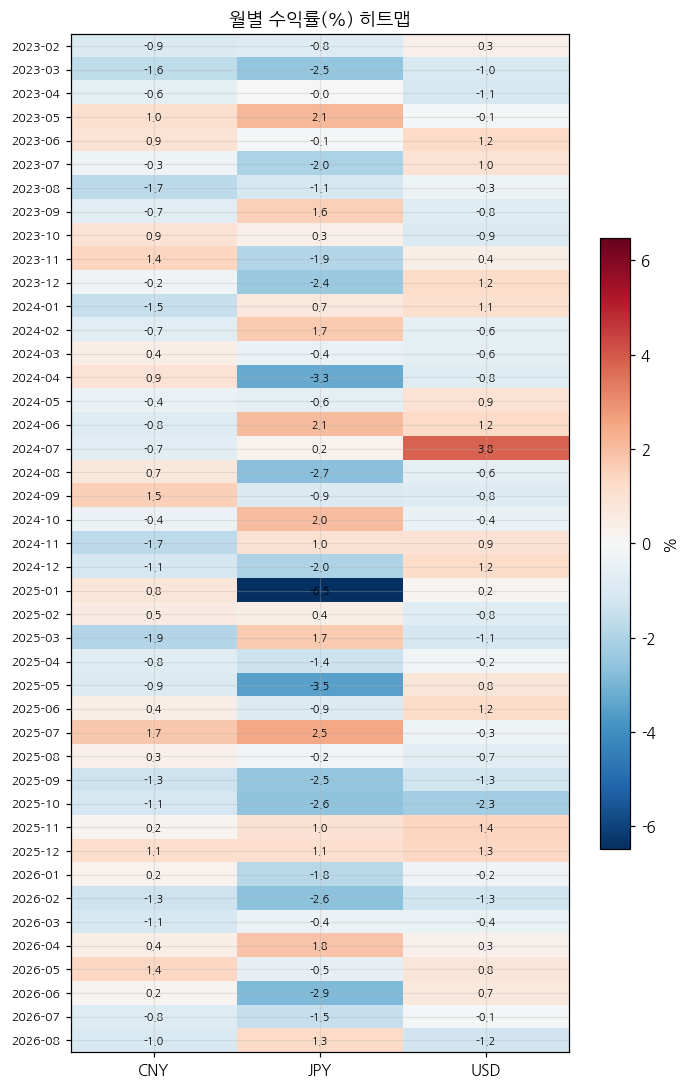

In [6]:
mret = az.monthly_return(wide).dropna(how="all")
mret_display = mret.copy()
mret_display.index = mret_display.index.strftime("%Y-%m")

fig, ax = plt.subplots(figsize=(6.5, 10))
im = ax.imshow(mret_display.values, cmap="RdBu_r", aspect="auto",
               vmin=-np.nanmax(np.abs(mret_display.values)),
               vmax=np.nanmax(np.abs(mret_display.values)))
ax.set_yticks(range(len(mret_display.index)))
ax.set_yticklabels(mret_display.index, fontsize=8)
ax.set_xticks(range(len(mret_display.columns)))
ax.set_xticklabels(mret_display.columns)
for i in range(mret_display.shape[0]):
    for j in range(mret_display.shape[1]):
        v = mret_display.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.1f}", ha="center", va="center", fontsize=7)
ax.set_title("월별 수익률(%) 히트맵")
fig.colorbar(im, ax=ax, shrink=0.6, label="%")
fig.tight_layout()
fig.savefig("images/03_monthly_return_heatmap.png", bbox_inches="tight")
plt.show()


## 7. [보너스 A] 시계열 분해 — USD 추세/계절성 분리

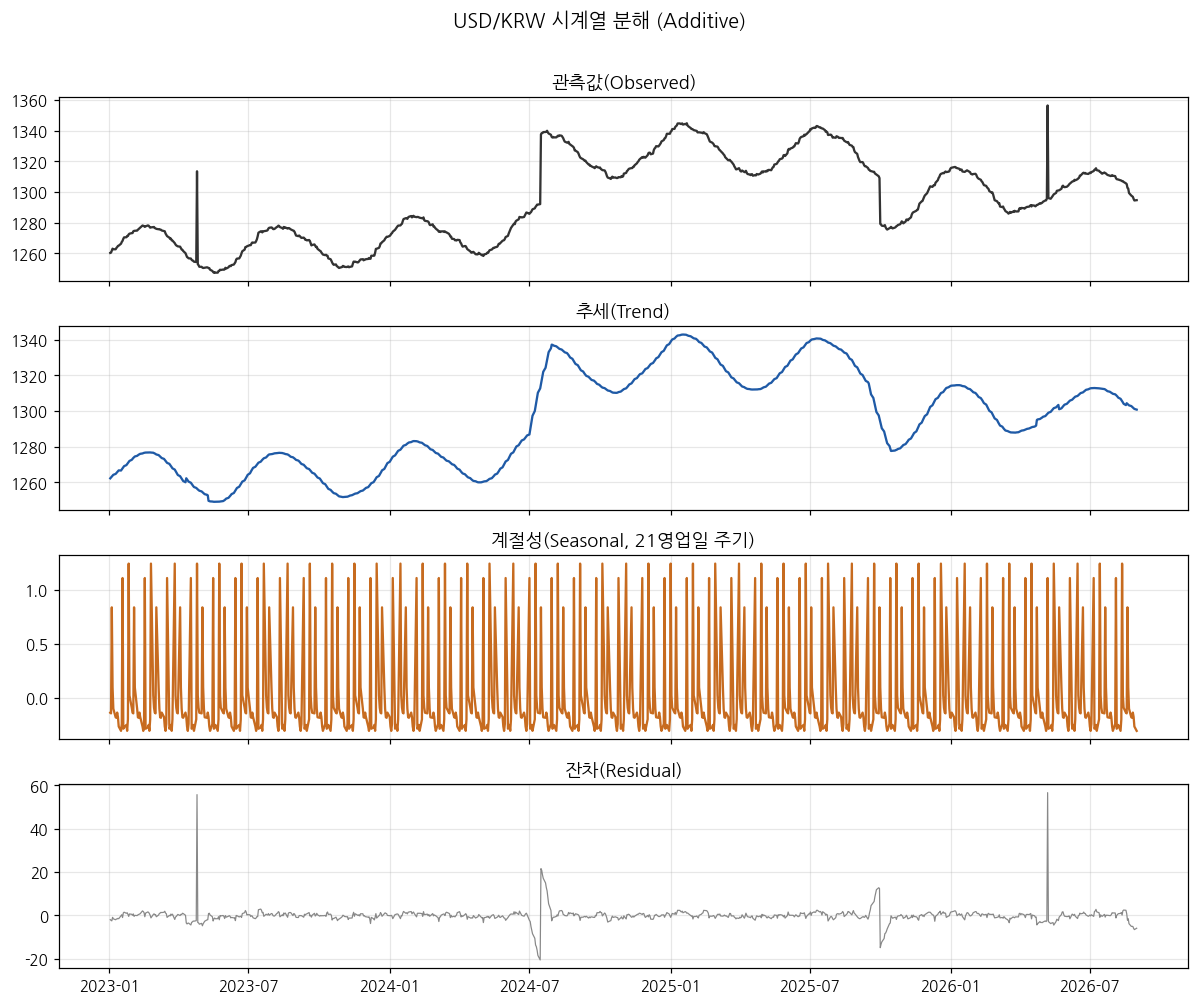

잔차 표준편차: 3.75 / 원계열 표준편차: 27.85


In [7]:
decomp = az.decompose(wide, "USD", period=21)  # 21영업일 ≈ 1개월

fig, axes = plt.subplots(4, 1, figsize=(11, 9), sharex=True)
axes[0].plot(decomp.observed, color="#333"); axes[0].set_title("관측값(Observed)")
axes[1].plot(decomp.trend, color="#1f5aa6"); axes[1].set_title("추세(Trend)")
axes[2].plot(decomp.seasonal, color="#c76b1f"); axes[2].set_title("계절성(Seasonal, 21영업일 주기)")
axes[3].plot(decomp.resid, color="#888", lw=0.8); axes[3].set_title("잔차(Residual)")
fig.suptitle("USD/KRW 시계열 분해 (Additive)", y=1.01, fontsize=13)
fig.tight_layout()
fig.savefig("images/04_decomposition_usd.png", bbox_inches="tight")
plt.show()

print("잔차 표준편차:", round(decomp.resid.std(), 2),
      "/ 원계열 표준편차:", round(wide['USD'].std(), 2))


**해석(가설)**: 잔차의 표준편차가 원계열 대비 크게 줄어든다면, 추세+21영업일 계절
성분이 변동의 상당 부분을 설명한다는 뜻이다. 다만 21영업일 주기는 '월 단위 패턴이
있을 것'이라는 가정에서 선택한 값이며, 실제로 뚜렷한 월 주기가 없다면 계절 성분은
과적합된 잡음일 수 있다는 한계가 있다.


## 8. [보너스 B] 베이스라인(단순) 예측 — 최근 추세 선형 연장

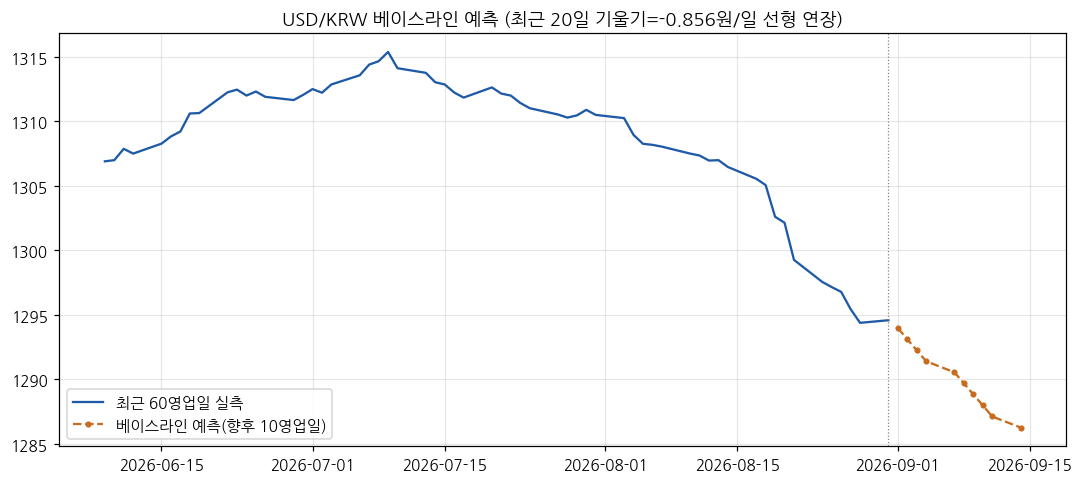

In [8]:
forecast, slope = az.naive_forecast(wide, "USD", horizon=10, window=20)

fig, ax = plt.subplots(figsize=(10, 4.5))
recent = wide["USD"].iloc[-60:]
ax.plot(recent.index, recent.values, color="#1f5aa6", label="최근 60영업일 실측")
ax.plot(forecast.index, forecast.values, color="#c76b1f", ls="--", marker="o",
        ms=3, label="베이스라인 예측(향후 10영업일)")
ax.axvline(recent.index[-1], color="gray", lw=0.8, ls=":")
ax.set_title(f"USD/KRW 베이스라인 예측 (최근 20일 기울기={slope:.3f}원/일 선형 연장)")
ax.legend()
fig.tight_layout()
fig.savefig("images/05_naive_forecast_usd.png", bbox_inches="tight")
plt.show()


**가정과 한계**: 이 예측은 정확도를 목표로 하지 않는 베이스라인이다.
- 가정: 최근 20영업일의 선형 추세가 향후에도 그대로 유지된다.
- 한계: 환율은 금리·수급·지정학 이벤트에 즉각 반응하는 자산이라 선형 추세가
  단기간 내에도 쉽게 꺾일 수 있다. 실제 예측이라면 ARIMA/외생변수(금리차 등)를
  포함한 모델과 백테스트가 필요하다.


## 9. 통화 간 상관관계 (참고)

In [9]:
corr = wide.pct_change().corr()
print(corr.round(3))


currency    CNY    JPY    USD
currency                     
CNY       1.000 -0.015  0.017
JPY      -0.015  1.000 -0.012
USD       0.017 -0.012  1.000


## 10. 인사이트 요약 (관찰 → 해석 → 액션)

아래는 위 시각화/통계에서 도출한 인사이트다. 자세한 서술은 `REPORT.md`를 참고.


In [10]:
summary = {
    "USD 전체 변화율(%)": round((wide['USD'].iloc[-1] / wide['USD'].iloc[0] - 1) * 100, 2),
    "JPY 전체 변화율(%)": round((wide['JPY'].iloc[-1] / wide['JPY'].iloc[0] - 1) * 100, 2),
    "CNY 전체 변화율(%)": round((wide['CNY'].iloc[-1] / wide['CNY'].iloc[0] - 1) * 100, 2),
    "USD 변동성(일간 표준편차 %)": round(ret['USD'].std(), 3),
    "JPY 변동성(일간 표준편차 %)": round(ret['JPY'].std(), 3),
    "CNY 변동성(일간 표준편차 %)": round(ret['CNY'].std(), 3),
}
for k, v in summary.items():
    print(f"{k}: {v}")


USD 전체 변화율(%): 2.73
JPY 전체 변화율(%): -23.12
CNY 전체 변화율(%): -7.91
USD 변동성(일간 표준편차 %): 0.334
JPY 변동성(일간 표준편차 %): 0.179
CNY 변동성(일간 표준편차 %): 0.1
